In [36]:
import pandas as pd
import sqlite3
from scipy import stats

In [37]:
conn = sqlite3.connect('lol_champions.db')

df = pd.read_sql("select attack_type, hp, armor, magic_resist, move_speed from champions", conn)
conn.close()
print(df.head())
print(df.shape)

  attack_type   hp  armor  magic_resist  move_speed
0       MELEE  650     38            32         345
1      RANGED  590     21            30         330
2       MELEE  600     23            37         345
3      RANGED  630     26            30         330
4       MELEE  685     40            32         330
(171, 5)


In [38]:
melee_hp = df[df['attack_type'] == 'MELEE']['hp']
ranged_hp = df[df['attack_type'] == 'RANGED']['hp']
melee_armor = df[df['attack_type'] == 'MELEE']['armor']
ranged_armor = df[df['attack_type'] == 'RANGED']['armor']
melee_magic_resist = df[df['attack_type'] == 'MELEE']['magic_resist']
ranged_magic_resist = df[df['attack_type'] == 'RANGED']['magic_resist']
melee_move_speed = df[df['attack_type'] == 'MELEE']['move_speed']
ranged_move_speed = df[df['attack_type'] == 'RANGED']['move_speed']

stats.ttest_ind(melee_hp, ranged_hp)

TtestResult(statistic=7.267775295179626, pvalue=1.2895781095332174e-11, df=169.0)

In [39]:
stats.ttest_ind(melee_armor, ranged_armor)


TtestResult(statistic=13.073094607637955, pvalue=1.9534631882223924e-27, df=169.0)

In [40]:
stats.ttest_ind(melee_magic_resist, ranged_magic_resist)

TtestResult(statistic=6.519207971036368, pvalue=7.832961036256288e-10, df=169.0)

In [41]:
stats.ttest_ind(melee_move_speed, ranged_move_speed)

TtestResult(statistic=8.406420247207759, pvalue=1.6829190207438674e-14, df=169.0)

In [42]:
era_conn = sqlite3.connect('lol_champions.db')
era_df = pd.read_sql('select release_year, hp, armor, magic_resist, move_speed, attack_damage from champions', era_conn)
era_conn.close()

print(era_df.head())

   release_year   hp  armor  magic_resist  move_speed  attack_damage
0          2013  650     38            32         345             60
1          2011  590     21            30         330             53
2          2010  600     23            37         345             62
3          2021  630     26            30         330             52
4          2009  685     40            32         330             62


In [43]:
eras = []

for year in era_df['release_year']:
    if year <= 2011:
        eras.append('Launch')
    elif year <= 2018:
        eras.append('Mid')
    else:
        eras.append('Modern')

era_df["era"] = eras


In [44]:
print(era_df.head())

   release_year   hp  armor  magic_resist  move_speed  attack_damage     era
0          2013  650     38            32         345             60     Mid
1          2011  590     21            30         330             53  Launch
2          2010  600     23            37         345             62  Launch
3          2021  630     26            30         330             52  Modern
4          2009  685     40            32         330             62  Launch


In [45]:
launch_hp = era_df[era_df['era'] == 'Launch']['hp']
mid_hp = era_df[era_df['era'] == 'Mid']['hp']
modern_hp = era_df[era_df['era'] == 'Modern']['hp']

stats.f_oneway(launch_hp, mid_hp, modern_hp)

F_onewayResult(statistic=6.014249257565102, pvalue=0.0030013308882588796)

In [46]:
launch_armor = era_df[era_df['era'] == 'Launch']['armor']
mid_armor = era_df[era_df['era'] == 'Mid']['armor']
modern_armor = era_df[era_df['era'] == 'Modern']['armor']

stats.f_oneway(launch_armor, mid_armor, modern_armor)

F_onewayResult(statistic=1.6774623926085293, pvalue=0.18996170008279922)

In [47]:
launch_mr = era_df[era_df['era'] == 'Launch']['magic_resist']
mid_mr = era_df[era_df['era'] == 'Mid']['magic_resist']
modern_mr = era_df[era_df['era'] == 'Modern']['magic_resist']

stats.f_oneway(launch_mr, mid_mr, modern_mr)

F_onewayResult(statistic=0.538389911967127, pvalue=0.5846909452939995)

In [48]:
launch_ms = era_df[era_df['era'] == 'Launch']['move_speed']
mid_ms = era_df[era_df['era'] == 'Mid']['move_speed']
modern_ms = era_df[era_df['era'] == 'Modern']['move_speed']

stats.f_oneway(launch_ms, mid_ms, modern_ms)

F_onewayResult(statistic=2.4212199193715103, pvalue=0.09190667588315064)

In [49]:
import statsmodels.stats.multicomp as mc

tukey_result = mc.pairwise_tukeyhsd(
    endog= era_df['hp'],
    groups = era_df['era'],
    alpha = 0.05
)
print(tukey_result)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
Launch    Mid -11.3291 0.2058 -27.0284  4.3702  False
Launch Modern -27.5996 0.0025 -46.8444 -8.3549   True
   Mid Modern -16.2706 0.1592 -37.1587  4.6176  False
-----------------------------------------------------


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

melee_ranged_avg = df.groupby('attack_type')[['hp', 'armor', 'magic_resist', 'move_speed']].mean()

melee_ranged_avg = melee_ranged_avg.reset_index()

melee_ranged_melted = melee_ranged_avg.melt(
    id_vars = "attack_type",
    var_name = 'stat',
    value_name = 'value'
)

print(melee_ranged_melted)

  attack_type          stat       value
0       MELEE            hp  636.352273
1      RANGED            hp  598.168675
2       MELEE         armor   33.545455
3      RANGED         armor   25.265060
4       MELEE  magic_resist   31.443182
5      RANGED  magic_resist   29.975904
6       MELEE    move_speed  339.715909
7      RANGED    move_speed  331.542169


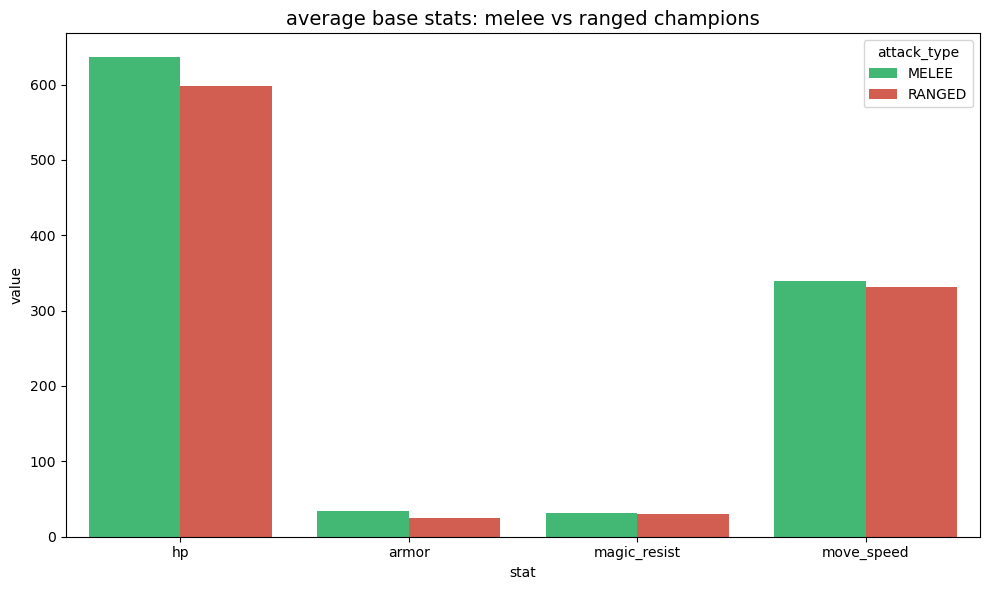

In [51]:
plt.figure(figsize = (10,6))

sns.barplot(
    data = melee_ranged_melted,
    x = 'stat',
    y = 'value',
    hue = 'attack_type',
    palette =["#2ecc71", "#e74c3c"]
)

plt.title('average base stats: melee vs ranged champions', fontsize = 14)
plt.xlabel('stat')
plt.ylabel('value')
plt.legend(title='attack_type')

plt.tight_layout()
plt.savefig("melee_vs_ranged_stats.png", dpi=150)
plt.show()

In [54]:
melee_ranged_avg = melee_ranged_avg.set_index('attack_type')
print(melee_ranged_avg)

                     hp      armor  magic_resist  move_speed
attack_type                                                 
MELEE        636.352273  33.545455     31.443182  339.715909
RANGED       598.168675  25.265060     29.975904  331.542169


In [58]:
pct_diff = pd.DataFrame({
    "stat": ['hp', 'armor', 'magic_resist', 'move_speed'],
    'pct_advantage': [
        ((melee_ranged_avg.loc['MELEE', 'hp'] - melee_ranged_avg.loc['RANGED', 'hp']) / melee_ranged_avg.loc['RANGED', 'hp']) * 100,
        ((melee_ranged_avg.loc['MELEE', 'armor'] - melee_ranged_avg.loc['RANGED', 'armor']) / melee_ranged_avg.loc['RANGED', 'armor']) * 100,
        ((melee_ranged_avg.loc['MELEE', 'magic_resist'] - melee_ranged_avg.loc['RANGED', 'magic_resist']) / melee_ranged_avg.loc['RANGED', 'magic_resist']) * 100,
        ((melee_ranged_avg.loc['MELEE', 'move_speed'] - melee_ranged_avg.loc['RANGED', 'move_speed']) / melee_ranged_avg.loc['RANGED', 'move_speed']) *100
    ]
})

pct_diff = pct_diff.sort_values('pct_advantage', ascending=True)

print(pct_diff)

           stat  pct_advantage
3    move_speed       2.465370
2  magic_resist       4.894859
0            hp       6.383417
1         armor      32.774093


/var/folders/yy/g1q3krl52yv0ynb5_jw4j0tw0000gn/T/ipykernel_74830/4033894867.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


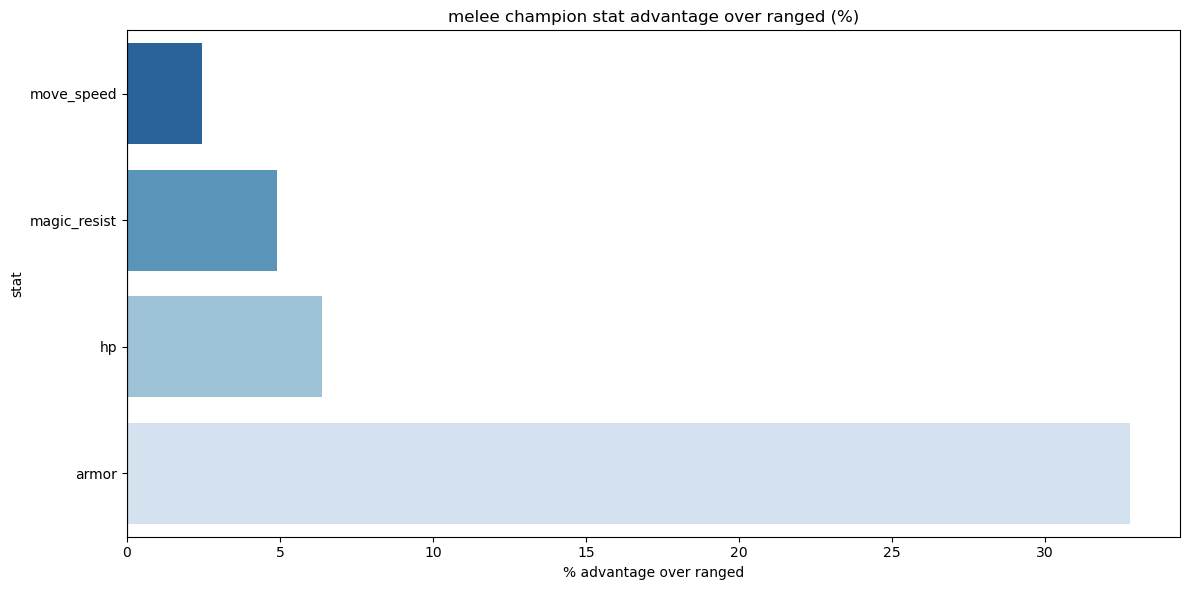

In [59]:
plt.figure(figsize=(12,6))

sns.barplot(
    data = pct_diff,
    x='pct_advantage',
    y='stat',
    palette = 'Blues_r'
)

plt.axvline(x=0, color = 'black', linewidth=0.8)
plt.title('melee champion stat advantage over ranged (%)')
plt.xlabel('% advantage over ranged')
plt.ylabel('stat')

plt.savefig('melee_vs_ranged_pct_advantage.png', dpi=150)
plt.tight_layout()
plt.show()

In [ ]:
era_hp_avg = era_df.groupby('era')['hp'].mean()
print(era_hp_avg)

era
Launch    625.944444
Mid       614.615385
Modern    598.344828
Name: hp, dtype: float64


/var/folders/yy/g1q3krl52yv0ynb5_jw4j0tw0000gn/T/ipykernel_74830/2056958114.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


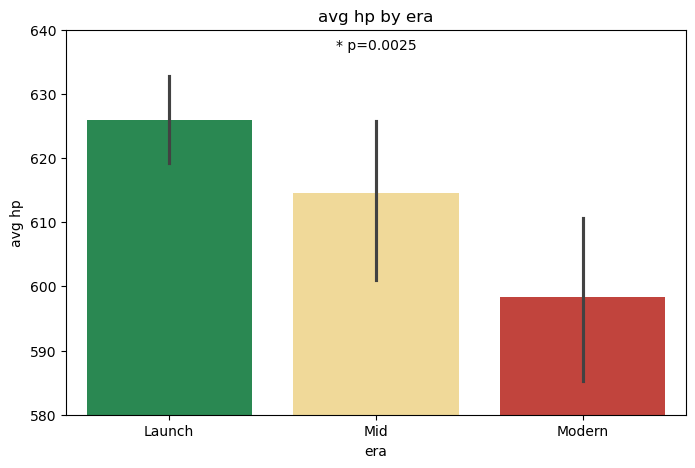

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data = era_df,
    x='era',
    y='hp',
    order=['Launch', 'Mid', 'Modern'],
    palette=["#1a9850", "#fee08b", "#d73027"]
)

plt.ylim(580, 640)
plt.annotate ("* p=0.0025",
              xy=(0.5, 0.95),
              xycoords = 'axes fraction',
              ha='center',
              fontsize=10,
              color='black')

plt.title('avg hp by era')
plt.xlabel('era')
plt.ylabel('avg hp')
plt.savefig("avg_hp_by_era.png", dpi=150)
plt.show()

In [ ]:
role_conn = sqlite3.connect('lol_champions.db')

role_df = pd.read_sql('select r.champion_id, c.release_year, r.role from champions c join champion_roles r on c.id = r.champion_id', role_conn)

role_conn.close()

print(role_df.head())
print(role_df.shape)


   champion_id  release_year        role
0            1          2013     FIGHTER
1            1          2013  JUGGERNAUT
2            1          2013        TANK
3            2          2011    ASSASSIN
4            2          2011       BURST
(457, 3)


In [ ]:
core_roles = ['FIGHTER', 'MAGE', 'ASSASSIN', 'SUPPORT', 'TANK', 'MARKSMAN']
role_df = role_df[role_df['role'].isin(core_roles)]

print(role_df.shape)

(313, 3)


In [ ]:
eras = []

for year in role_df['release_year']:
    if year <= 2011:
        eras.append('Launch')
    elif year <= 2018:
        eras.append('Mid')
    else:
        eras.append('Modern')

role_df['era'] = eras

role_counts = role_df.groupby(['era', 'role'])['champion_id'].count().reset_index()
role_counts.columns = ['era', 'role', 'count']

print(role_counts)

       era      role  count
0   Launch  ASSASSIN     22
1   Launch   FIGHTER     34
2   Launch      MAGE     45
3   Launch  MARKSMAN     15
4   Launch   SUPPORT     22
5   Launch      TANK     30
6      Mid  ASSASSIN     14
7      Mid   FIGHTER     18
8      Mid      MAGE     19
9      Mid  MARKSMAN     12
10     Mid   SUPPORT     15
11     Mid      TANK     14
12  Modern  ASSASSIN     12
13  Modern   FIGHTER     12
14  Modern      MAGE     11
15  Modern  MARKSMAN      7
16  Modern   SUPPORT      8
17  Modern      TANK      3


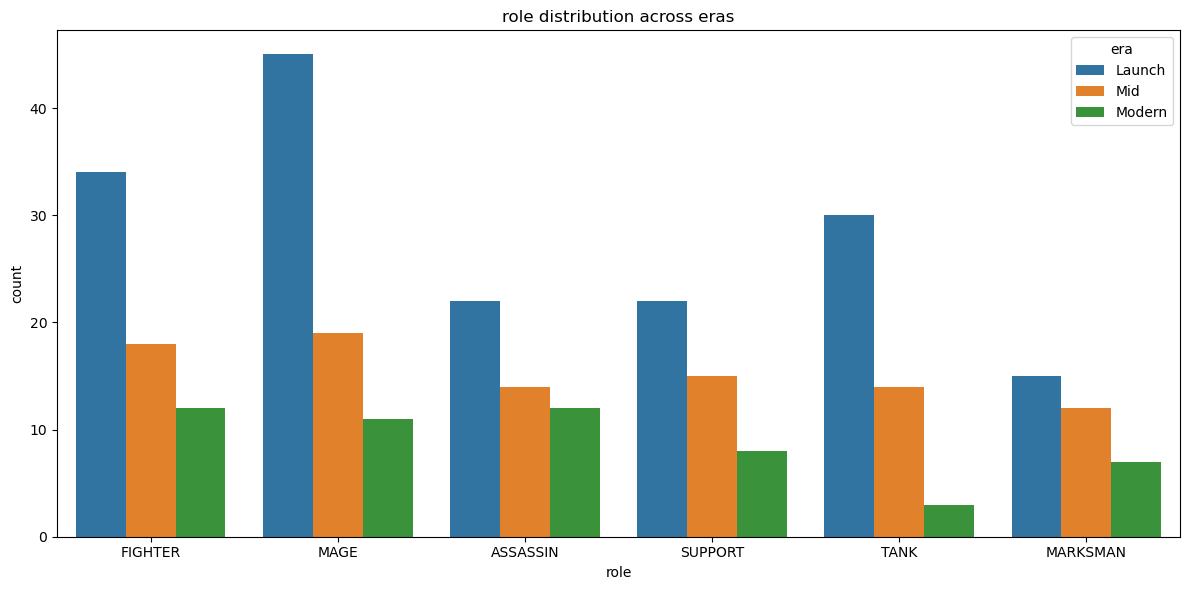

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data = role_counts,
    x='role',
    y='count',
    hue = 'era',
    order = ["FIGHTER", 'MAGE', 'ASSASSIN', 'SUPPORT', 'TANK', 'MARKSMAN'],
    hue_order = ['Launch', 'Mid', 'Modern']
)

plt.title('role distribution across eras')
plt.xlabel('role')
plt.ylabel('count')
plt.legend(title = 'era')
plt.savefig('role_distribution_by_era.png', dpi=150)
plt.tight_layout()
plt.show()

In [ ]:
role_counts['era_total'] = role_counts.groupby('era')['count'].transform('sum')
role_counts['proportion'] = (role_counts['count'] / role_counts['era_total']) * 100

print(role_counts.head(10))

      era      role  count  era_total  proportion
0  Launch  ASSASSIN     22        168   13.095238
1  Launch   FIGHTER     34        168   20.238095
2  Launch      MAGE     45        168   26.785714
3  Launch  MARKSMAN     15        168    8.928571
4  Launch   SUPPORT     22        168   13.095238
5  Launch      TANK     30        168   17.857143
6     Mid  ASSASSIN     14         92   15.217391
7     Mid   FIGHTER     18         92   19.565217
8     Mid      MAGE     19         92   20.652174
9     Mid  MARKSMAN     12         92   13.043478


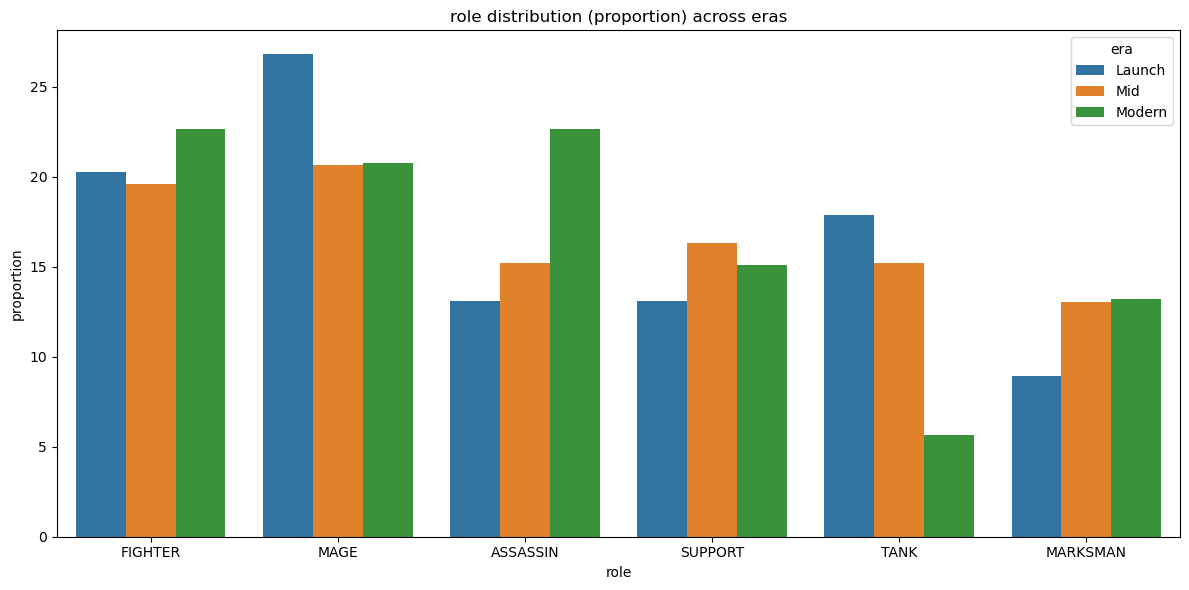

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data = role_counts,
    x = 'role',
    y = 'proportion',
    hue = 'era',
    order = ['FIGHTER', 'MAGE', 'ASSASSIN', 'SUPPORT', 'TANK', 'MARKSMAN'],
    hue_order = ['Launch', 'Mid', 'Modern']
)

plt.title('role distribution (proportion) across eras')
plt.xlabel('role')
plt.ylabel('proportion')
plt.legend(title='era')
plt.savefig('role_distribution_(proportion)_by_era.png', dpi=150)
plt.tight_layout()
plt.show()